# HAPPINESS DATA ANALYSIS

This data analysis explores the key factors influencing happiness levels across countries using the World Happiness Report 2021 dataset. The dataset contains comprehensive metrics for multiple nations, measuring subjective well-being through the Ladder Score (happiness index) along with various socio-economic and psychological indicators.

The primary objective of the project is to identify patterns, relationships, and key drivers of happiness on a global scale. Variables such as GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption are analyzed to understand how they contribute to overall life satisfaction.

## IMPORTANT LIBERARIES

In [1]:
from pyexpat import features
from statistics import mode

import pandas as pd     # data handiling
import matplotlib.pyplot as plt   # visualaization
import seaborn as sns     # visualization
from pandas.io.sas.sas_constants import dataset_length
from seaborn import categorical

## DATA LOADING

In [2]:
df=pd.read_csv("world happiness report.csv")
df

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


## INSPECT THE DATA

In [3]:
df.head(5)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [4]:
df.tail(5)


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205
148,Afghanistan,South Asia,2.523,0.038,2.596,2.449,7.695,0.463,52.493,0.382,-0.102,0.924,2.43,0.370,0.000,0.126,0.000,0.122,0.010,1.895


## CHECK COLUMNS DATA TYPES

In [5]:
df.dtypes #CHECK THE DATA  TYPE


Country name                                   object
Regional indicator                             object
Ladder score                                  float64
Standard error of ladder score                float64
upperwhisker                                  float64
lowerwhisker                                  float64
Logged GDP per capita                         float64
Social support                                float64
Healthy life expectancy                       float64
Freedom to make life choices                  float64
Generosity                                    float64
Perceptions of corruption                     float64
Ladder score in Dystopia                      float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generosity                      float64
Explained by: Perceptions of

## CHECK COLUMNS NAME

In [6]:

df.columns # DISPLAY COLUMNS NAMES

Index(['Country name', 'Regional indicator', 'Ladder score',
       'Standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Ladder score in Dystopia',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

## CHECK COLUMNS SHAPE

In [7]:
df.shape # DISPLAY NO. OF ROW AND COLUMNS

(149, 20)

## CHECK INFORMATION

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

## OVERVIEW


No missing value- clean dataset


mostly numerical data (18 columns)+2 categorical


main variable ladder score (happiness score)


include factors like GDP,social support life expectancy,freedom


suitable for data analysis and visualizations

## SELECTING COLUMN

In [9]:
df['Country name']



0          Finland
1          Denmark
2      Switzerland
3          Iceland
4      Netherlands
          ...     
144        Lesotho
145       Botswana
146         Rwanda
147       Zimbabwe
148    Afghanistan
Name: Country name, Length: 149, dtype: object

## SELECTING MULTIPLE COLUMN

In [10]:
df[['Regional indicator','Healthy life expectancy']]

,Regional indicator,Healthy life expectancy
0,Western Europe,72.000
1,Western Europe,72.700
2,Western Europe,74.400
3,Western Europe,73.000
4,Western Europe,72.400
...,...,...
144,Sub-Saharan Africa,48.700
145,Sub-Saharan Africa,59.269
146,Sub-Saharan Africa,61.400
147,Sub-Saharan Africa,56.201


## FILTERING DATA

In [11]:
df[df['Ladder score']<7]

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
17,Czech Republic,Central and Eastern Europe,6.965,0.049,7.062,6.868,10.556,0.947,70.807,0.858,-0.208,0.868,2.43,1.370,1.090,0.703,0.580,0.052,0.046,3.124
18,United States,North America and ANZ,6.951,0.049,7.047,6.856,11.023,0.920,68.200,0.837,0.098,0.698,2.43,1.533,1.030,0.621,0.554,0.252,0.154,2.807
19,Belgium,Western Europe,6.834,0.034,6.901,6.767,10.823,0.906,72.199,0.783,-0.153,0.646,2.43,1.463,0.998,0.747,0.489,0.088,0.187,2.862
20,France,Western Europe,6.690,0.037,6.762,6.618,10.704,0.942,74.000,0.822,-0.147,0.571,2.43,1.421,1.081,0.804,0.536,0.092,0.235,2.521
21,Bahrain,Middle East and North Africa,6.647,0.068,6.779,6.514,10.669,0.862,69.495,0.925,0.089,0.722,2.43,1.409,0.899,0.662,0.661,0.246,0.139,2.631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


## FILTERING MULTIPLE DATA

In [12]:
df[(df['Regional indicator']=='South Asia')&(df["lowerwhisker"]>5.000)]

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
86,Nepal,South Asia,5.269,0.070,5.406,5.132,8.120,0.774,64.233,0.782,0.152,0.727,2.43,0.519,0.702,0.496,0.488,0.287,0.135,2.642
88,Maldives,South Asia,5.198,0.072,5.339,5.057,9.826,0.913,70.600,0.854,0.024,0.825,2.43,1.115,1.015,0.697,0.575,0.204,0.073,1.520


## SELECTING ROWS

In [13]:
df.iloc[4:10]

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
5,Norway,Western Europe,7.392,0.035,7.462,7.323,11.053,0.954,73.3,0.960,0.093,0.270,2.43,1.543,1.108,0.782,0.703,0.249,0.427,2.580
6,Sweden,Western Europe,7.363,0.036,7.433,7.293,10.867,0.934,72.7,0.945,0.086,0.237,2.43,1.478,1.062,0.763,0.685,0.244,0.448,2.683
7,Luxembourg,Western Europe,7.324,0.037,7.396,7.252,11.647,0.908,72.6,0.907,-0.034,0.386,2.43,1.751,1.003,0.760,0.639,0.166,0.353,2.653
8,New Zealand,North America and ANZ,7.277,0.040,7.355,7.198,10.643,0.948,73.4,0.929,0.134,0.242,2.43,1.400,1.094,0.785,0.665,0.276,0.445,2.612
9,Austria,Western Europe,7.268,0.036,7.337,7.198,10.906,0.934,73.3,0.908,0.042,0.481,2.43,1.492,1.062,0.782,0.640,0.215,0.292,2.784


## LOC METHOD

In [14]:
df.loc[100,'Ladder score']

np.float64(5.025)

In [15]:
df.rename(columns={"Country name":"country"},inplace=True)

# DATA CLEANING

### RENAME COLUMN

In [16]:
df

,country,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


In [17]:
df.rename(columns={"Regional indicator": "region"}, inplace=True)


In [18]:
df

,country,region,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


In [19]:
"""df.['engine']=pd.to_numeric(
    df['engine']
    .astype(str)
    .str.replace(r'[^0-9.-]',' ',regex=True)
    .replace(' ',None),
    errors='coerce'
)"""                           #remove text unit and convert into numbers

"df.['engine']=pd.to_numeric(\n    df['engine']\n    .astype(str)\n    .str.replace(r'[^0-9.-]',' ',regex=True)\n    .replace(' ',None),\n    errors='coerce'\n)"

## Droping columns

In [20]:
df.drop(columns=['Ladder score in Dystopia','Explained by: Social support'],inplace=True)

In [21]:
df.drop(columns=['Explained by: Log GDP per capita', 'Explained by: Healthy life expectancy','Explained by: Freedom to make life choices','Explained by: Generosity','Explained by: Perceptions of corruption'], inplace=True)


In [22]:
df

,country,region,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Lesotho,Sub-Saharan Africa,3.512,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,1.800
145,Botswana,Sub-Saharan Africa,3.467,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,0.648
146,Rwanda,Sub-Saharan Africa,3.415,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,1.095
147,Zimbabwe,Sub-Saharan Africa,3.145,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,1.205


## HANDILING MISSING VALUES

In [23]:
df.isnull().sum()

country                           0
region                            0
Ladder score                      0
Standard error of ladder score    0
upperwhisker                      0
lowerwhisker                      0
Logged GDP per capita             0
Social support                    0
Healthy life expectancy           0
Freedom to make life choices      0
Generosity                        0
Perceptions of corruption         0
Dystopia + residual               0
dtype: int64

There is no missing value for filling data , droping columns

DAY-4

## HANDILING DUPLICATES

In [24]:
df.duplicated().sum()

np.int64(0)

## VERIFY DATA CLEANING

In [25]:
df.sample(10)

,country,region,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
44,Kazakhstan,Commonwealth of Independent States,6.152,0.047,6.243,6.060,10.155,0.952,65.200,0.853,-0.069,0.733,2.446
111,Gabon,Sub-Saharan Africa,4.852,0.075,4.998,4.706,9.603,0.776,59.962,0.731,-0.200,0.840,2.201
47,Serbia,Central and Eastern Europe,6.078,0.053,6.181,5.974,9.787,0.873,68.600,0.778,0.002,0.835,2.682
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.967
134,Madagascar,Sub-Saharan Africa,4.208,0.072,4.349,4.068,7.396,0.686,59.305,0.552,-0.005,0.803,2.620
41,Uzbekistan,Commonwealth of Independent States,6.179,0.068,6.312,6.045,8.836,0.918,65.255,0.970,0.311,0.515,2.477
65,Ecuador,Latin America and Caribbean,5.764,0.057,5.875,5.653,9.313,0.821,68.800,0.842,-0.124,0.843,2.653
85,Armenia,Commonwealth of Independent States,5.283,0.058,5.397,5.168,9.487,0.799,67.055,0.825,-0.168,0.629,2.127
135,Togo,Sub-Saharan Africa,4.107,0.077,4.258,3.956,7.362,0.569,54.914,0.619,0.032,0.772,2.806
14,Ireland,Western Europe,7.085,0.040,7.164,7.006,11.342,0.947,72.400,0.879,0.077,0.363,2.384


In [26]:
df.shape

(149, 13)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         149 non-null    object 
 1   region                          149 non-null    object 
 2   Ladder score                    149 non-null    float64
 3   Standard error of ladder score  149 non-null    float64
 4   upperwhisker                    149 non-null    float64
 5   lowerwhisker                    149 non-null    float64
 6   Logged GDP per capita           149 non-null    float64
 7   Social support                  149 non-null    float64
 8   Healthy life expectancy         149 non-null    float64
 9   Freedom to make life choices    149 non-null    float64
 10  Generosity                      149 non-null    float64
 11  Perceptions of corruption       149 non-null    float64
 12  Dystopia + residual             149 

In [28]:
df.columns

Index(['country', 'region', 'Ladder score', 'Standard error of ladder score',
       'upperwhisker', 'lowerwhisker', 'Logged GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Dystopia + residual'],
      dtype='object')

## SAVING CLEANED DATASET

In [29]:
df.to_csv('happiness_cleaned.csv',index=False)

LOAD DATSET

In [30]:
df_new=pd.read_csv("happiness_cleaned.csv")

In [31]:
df_new.head()

,country,region,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.798


## SUMMARY STATISTICS

### AVERAGE(mean)

In [32]:
print("upperwhisker  - ",df_new['upperwhisker'].mean())
print("upperwhisker  - ",df_new['upperwhisker'].mean())
print("Logged GDP per capita  - ",df_new['Logged GDP per capita'].mean())
print("Social support - ",df_new['Social support'].mean())
print("Healthy life expectancy  - ",df_new['Healthy life expectancy'].mean())

upperwhisker  -  5.648006711409396
upperwhisker  -  5.648006711409396
Logged GDP per capita  -  9.432208053691276
Social support -  0.8147449664429529
Healthy life expectancy  -  64.99279865771811


### MEDIAN

In [33]:
print("Freedom to make life choices  - ",df_new['Freedom to make life choices'].median())
print("Generosity  - ",df_new['Generosity'].median())
print("Logged GDP per capita  - ",df_new['Logged GDP per capita'].median())
print("Perceptions of corruption - ",df_new['Perceptions of corruption'].median())
print("Dystopia + residual - ",df_new['Dystopia + residual'].median())


Freedom to make life choices  -  0.804
Generosity  -  -0.036
Logged GDP per capita  -  9.569
Perceptions of corruption -  0.781
Dystopia + residual -  2.509


### MODE

In [34]:
print("Ladder score - ",df_new['Ladder score'].mode())
print("Ladder score - ",df_new['Ladder score'].mode())
print("Standard error of ladder score - ",df_new['Standard error of ladder score'].mode())

Ladder score -  0    5.477
1    5.929
Name: Ladder score, dtype: float64
Ladder score -  0    5.477
1    5.929
Name: Ladder score, dtype: float64
Standard error of ladder score -  0    0.046
Name: Standard error of ladder score, dtype: float64


In [35]:
df_new.select_dtypes(include='number').std()

Ladder score                      1.073924
Standard error of ladder score    0.022001
upperwhisker                      1.054330
lowerwhisker                      1.094879
Logged GDP per capita             1.158601
Social support                    0.114889
Healthy life expectancy           6.762043
Freedom to make life choices      0.113332
Generosity                        0.150657
Perceptions of corruption         0.179226
Dystopia + residual               0.537645
dtype: float64

In [36]:
df_new.select_dtypes(include='number').median()

Ladder score                       5.534
Standard error of ladder score     0.054
upperwhisker                       5.625
lowerwhisker                       5.413
Logged GDP per capita              9.569
Social support                     0.832
Healthy life expectancy           66.603
Freedom to make life choices       0.804
Generosity                        -0.036
Perceptions of corruption          0.781
Dystopia + residual                2.509
dtype: float64

In [37]:
df_new.select_dtypes(include='number').mean()

Ladder score                       5.532839
Standard error of ladder score     0.058752
upperwhisker                       5.648007
lowerwhisker                       5.417631
Logged GDP per capita              9.432208
Social support                     0.814745
Healthy life expectancy           64.992799
Freedom to make life choices       0.791597
Generosity                        -0.015134
Perceptions of corruption          0.727450
Dystopia + residual                2.430329
dtype: float64

In [38]:
df_new.describe()

,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.532839,0.058752,5.648007,5.417631,9.432208,0.814745,64.992799,0.791597,-0.015134,0.727450,2.430329
std,1.073924,0.022001,1.054330,1.094879,1.158601,0.114889,6.762043,0.113332,0.150657,0.179226,0.537645
min,2.523000,0.026000,2.596000,2.449000,6.635000,0.463000,48.478000,0.382000,-0.288000,0.082000,0.648000
25%,4.852000,0.043000,4.991000,4.706000,8.541000,0.750000,59.802000,0.718000,-0.126000,0.667000,2.138000
50%,5.534000,0.054000,5.625000,5.413000,9.569000,0.832000,66.603000,0.804000,-0.036000,0.781000,2.509000
75%,6.255000,0.070000,6.344000,6.128000,10.421000,0.905000,69.600000,0.877000,0.079000,0.845000,2.794000
max,7.842000,0.173000,7.904000,7.780000,11.647000,0.983000,76.953000,0.970000,0.542000,0.939000,3.482000


In [39]:
df_new.select_dtypes(include='object').mode()

,country,region
0,Afghanistan,Sub-Saharan Africa
1,Albania,NaN
2,Algeria,NaN
3,Argentina,NaN
4,Armenia,NaN
...,...,...
144,Venezuela,NaN
145,Vietnam,NaN
146,Yemen,NaN
147,Zambia,NaN


In [40]:
df.describe(include=object)

,country,region
count,149,149
unique,149,10
top,Finland,Sub-Saharan Africa
freq,1,36


## STATISTICAL SUMMARY INSIGHTS

* in the case of ladder score in dystopia-mean,min,persentiles and max are of the same value
* The data does not appear to be perfectly normally distributed.
* The distribution appears slightly skewed rather than fully symmetric.
* Mean and median differences may indicate some skewness in the data.
* The dataset appears complete with no significant null values.

* Standard Error of Ladder Score: Values seem closely grouped, suggesting low variation and near symmetry
* Lowerwhisker: Appears fairly symmetric.
* Logged GDP per Capita: Slightly skewed due to differences between countries, not perfectly normal.
* Social Support: Appears moderately symmetric, though slight skewness may exist.
* Healthy Life Expectancy: May show some skewness, but generally well distributed.
* Freedom to Make Life Choices: Slightly skewed and not perfectly normal.
* Generosity: Likely skewed because values vary widely.
* Perceptions of Corruption: Appears skewed and less symmetric.
* Dystopia + Residual: May show some variability and slight skewness.


* Each country appears only once, indicating no duplicate country entries.
* Since these are categorical variables, the output focuses on frequency and uniqueness, not numerical distribution.

## DATA VISUALIZATIONS

## Univariate analysis

### Histogram

* Distribution of continous numerical data

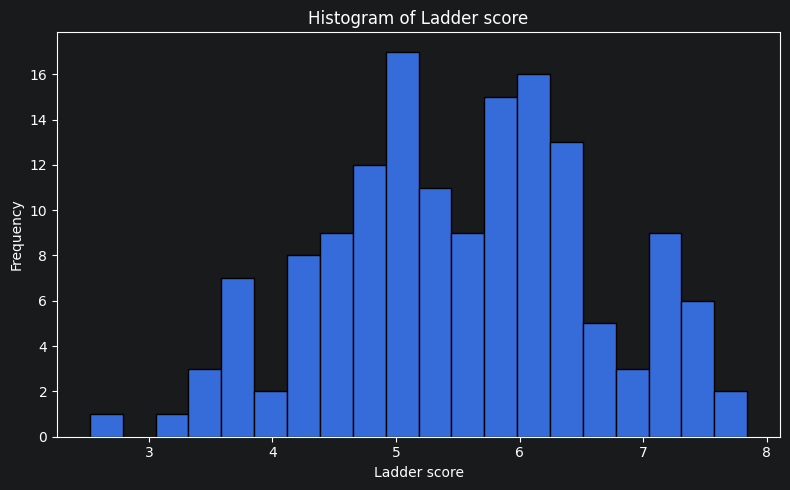

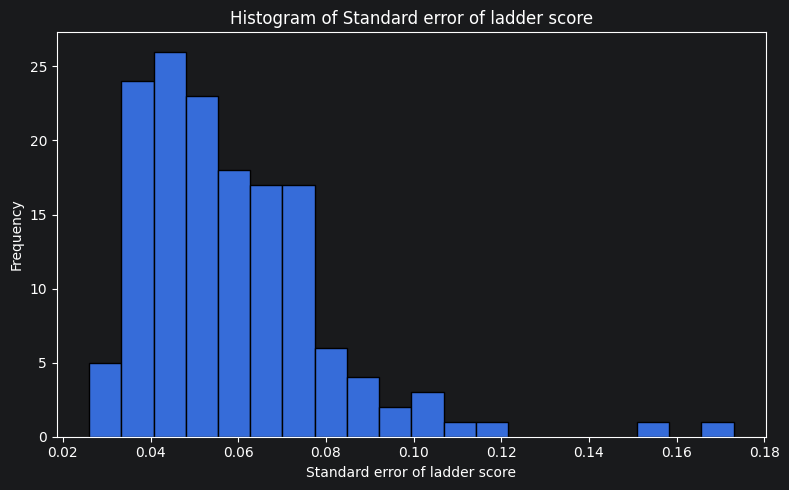

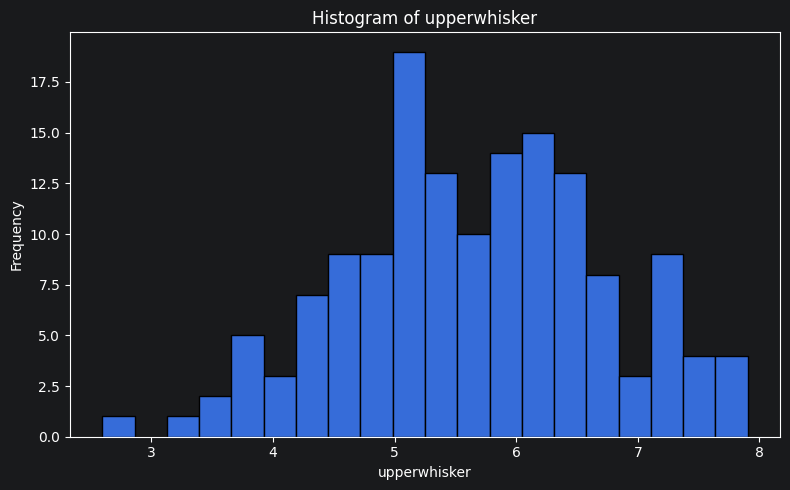

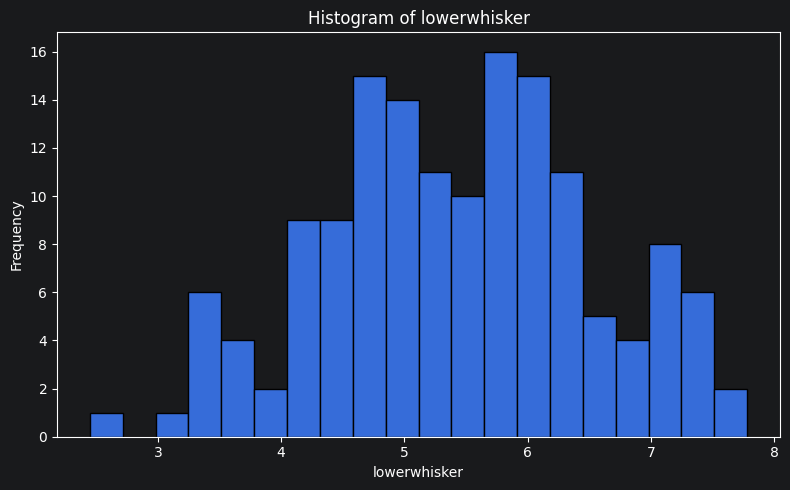

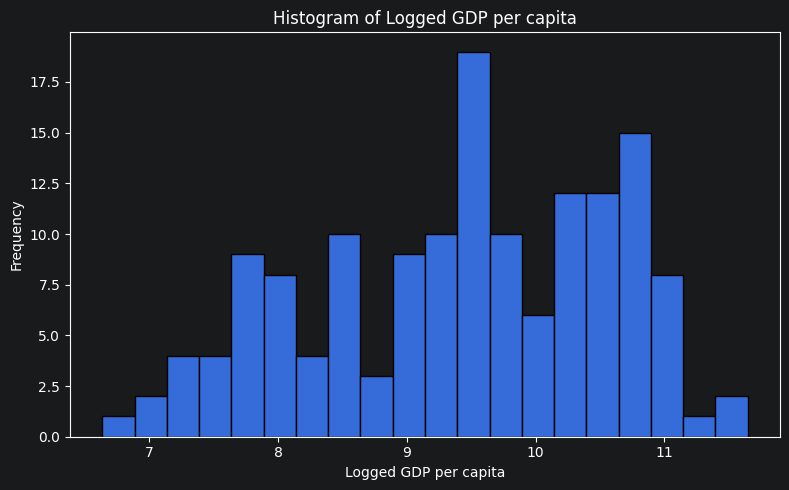

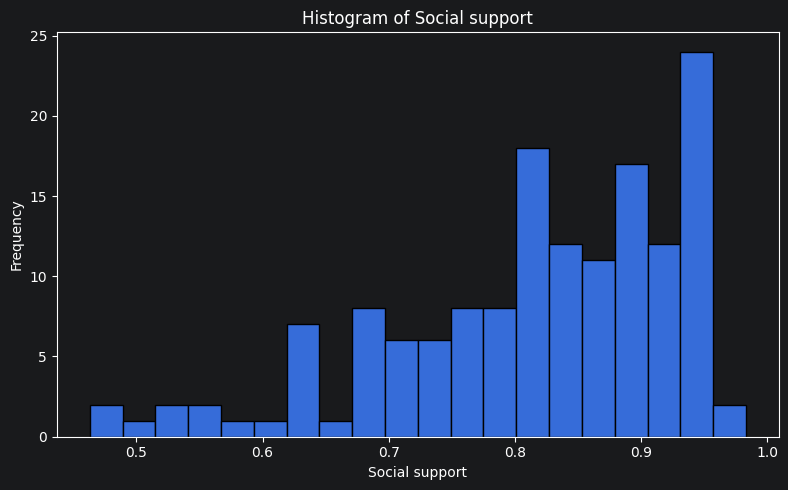

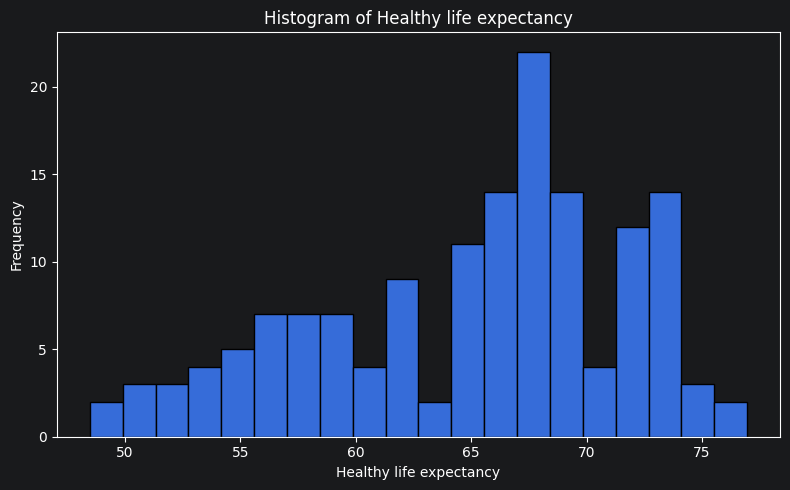

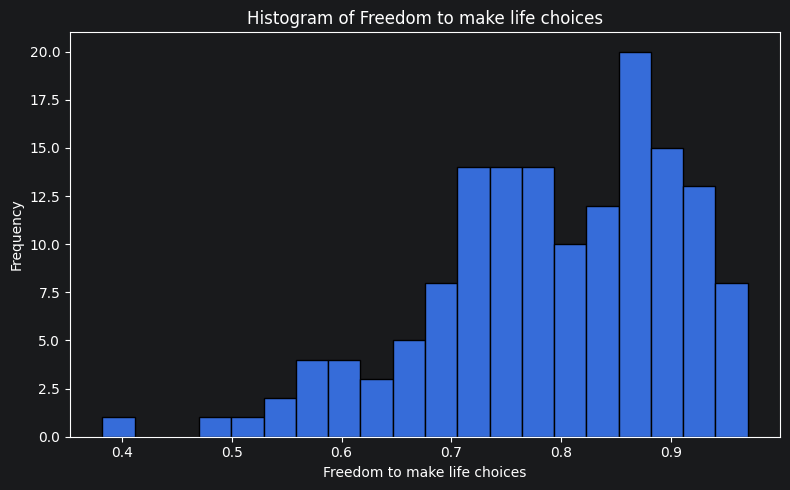

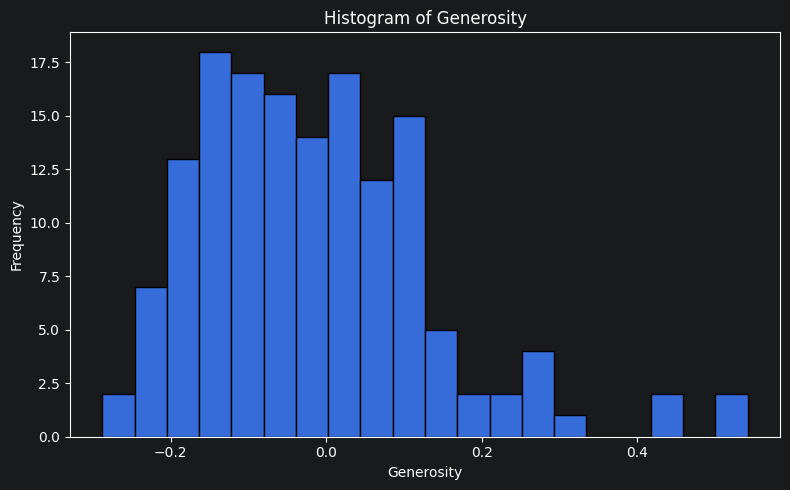

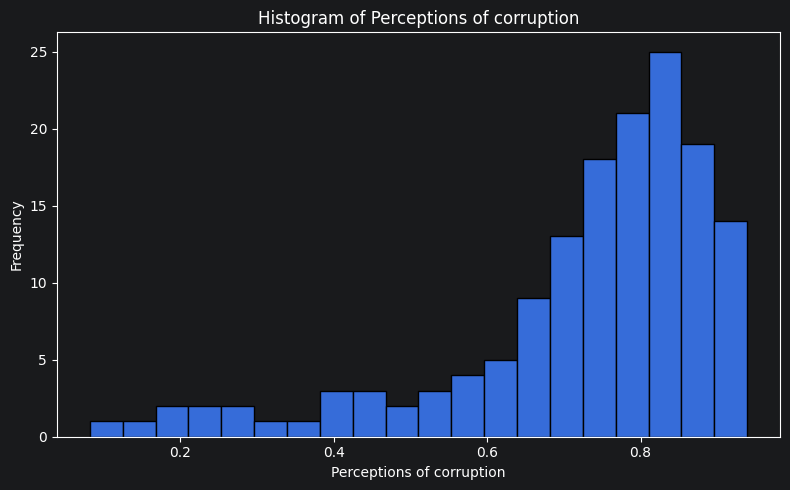

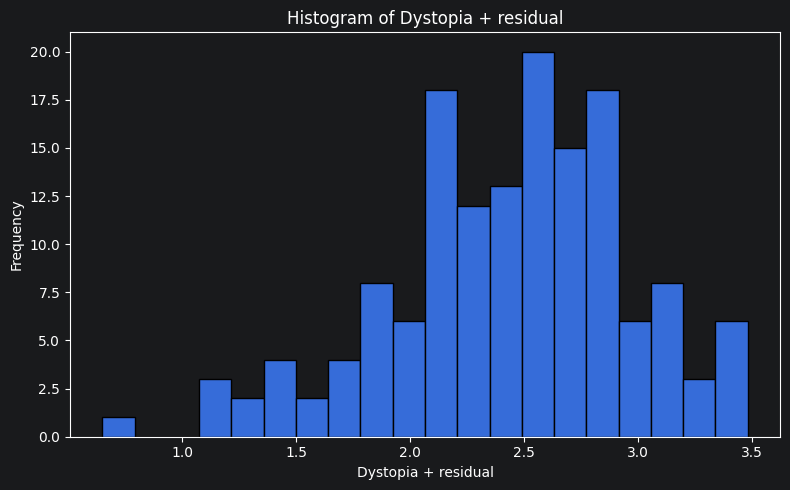

In [41]:
df_num = df_new.copy()
df_num.drop(columns=['region', 'country'], inplace=True)

for col in df_num.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_num[col].dropna(), bins=20, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Insights of Histogram

* Ladder Score: Moderate spread, nearly normal distribution.
* Standard Error of Ladder Score: Low variation, mostly concentrated.
* Upperwhisker: Moderate spread with slight variation.
* Lowerwhisker: Fairly balanced with some spread.
* Logged GDP per Capita: Moderate spread, slight skewness possible.
* Social Support: Mostly concentrated with low variation.
* Healthy Life Expectancy: Moderate spread, fairly balanced.
* Freedom to Make Life Choices: Some variation with slight skewness.
* Generosity: Higher spread and variability.
* Perceptions of Corruption: Wide variation, possible skewness.
* Dystopia + Residual: Moderate spread and distribution.

Day-6

## box plot

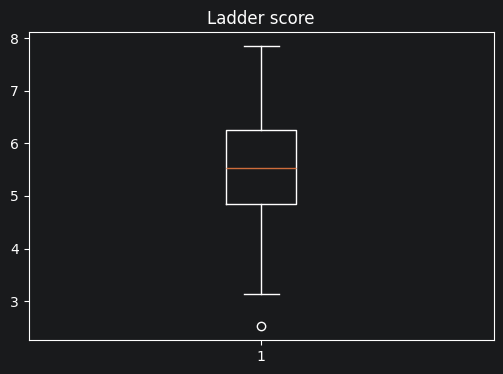

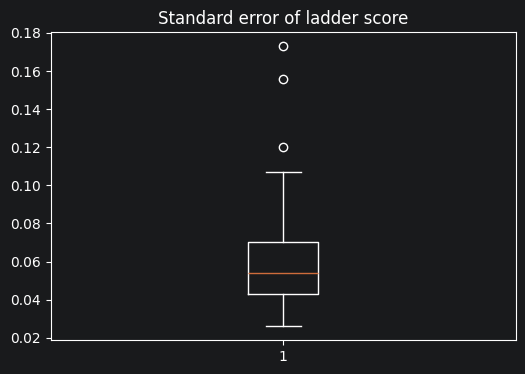

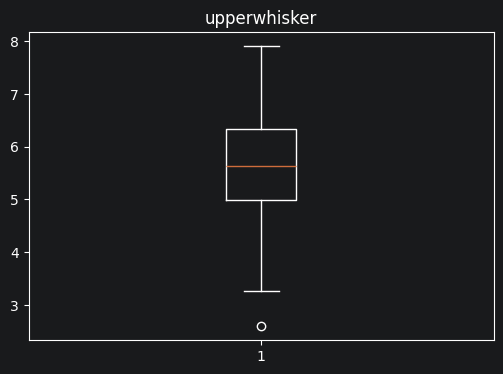

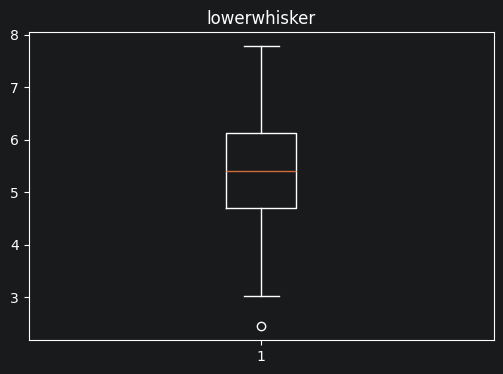

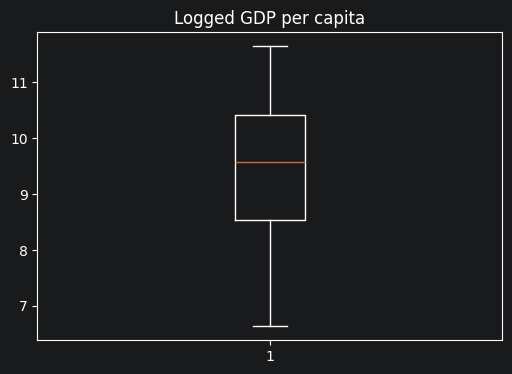

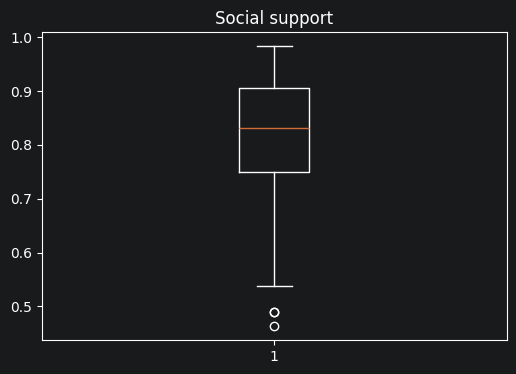

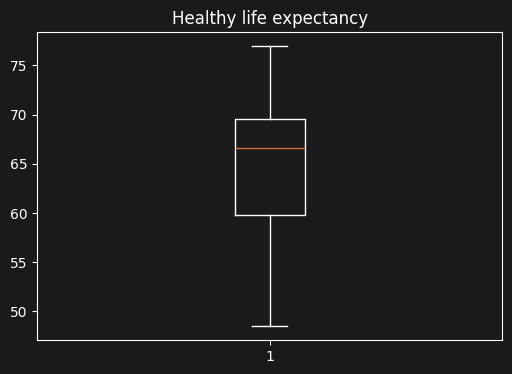

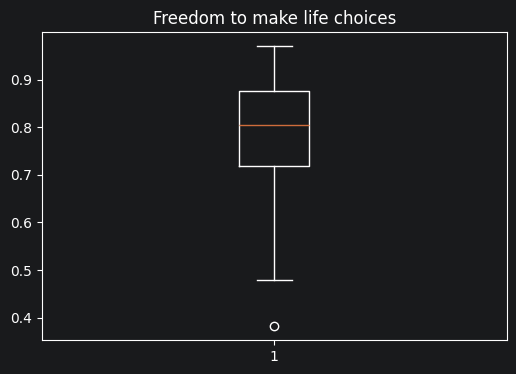

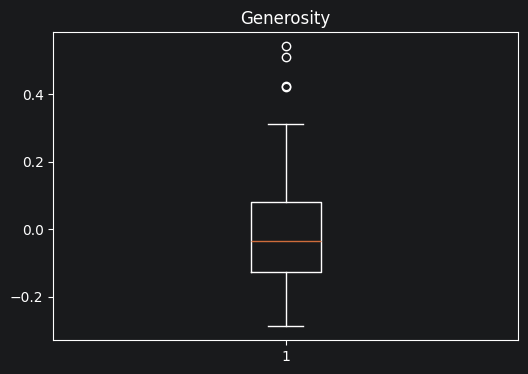

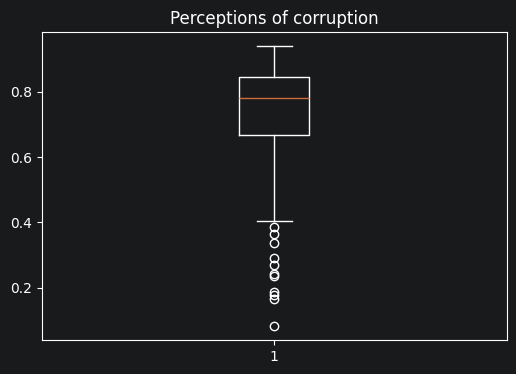

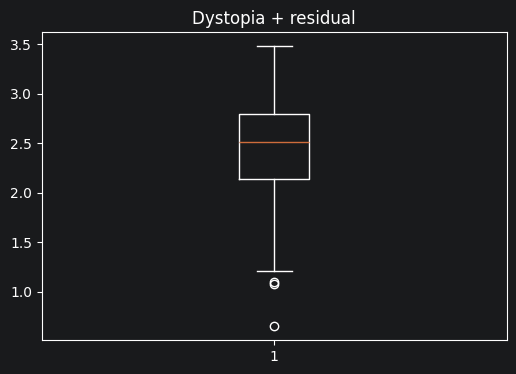

In [42]:
# df_num = df.copy()
# df_num.drop(columns=['region','country'],inplace=True)
# plt.figure(figsize=(40,40))
# df_num.boxplot(rot=45)
# plt.tight_layout()
# plt.show()
for col in df_num.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_num[col])
    plt.title(col)
    plt.show()

### INSIGHTS OF BOXPLOT

* Ladder Score: Moderate spread with some outliers.
* Standard Error of Ladder Score: Low spread, fairly consistent.
* Upperwhisker: Shows variation with possible high outliers.
* Lowerwhisker: Moderate spread with some extreme low values.
* Logged GDP per Capita: Noticeable variation and possible outliers.
* Social Support: Relatively consistent with moderate spread.
* Healthy Life Expectancy: Moderate variation with some outliers.
* Freedom to Make Life Choices: Shows some spread and slight skewness.
* Generosity: High variation with possible outliers.
* Perceptions of Corruption: Variable distribution with outliers.
* Dystopia + Residual: Moderate spread across countries.

### Kdeplot

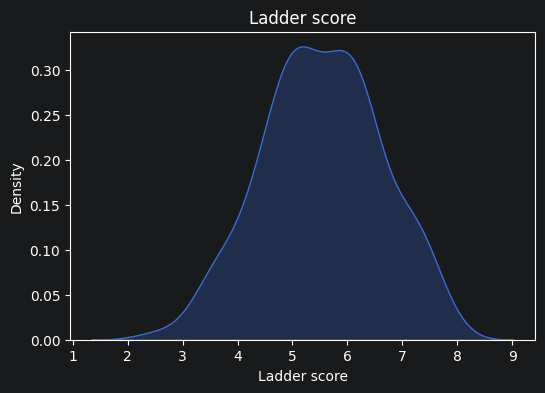

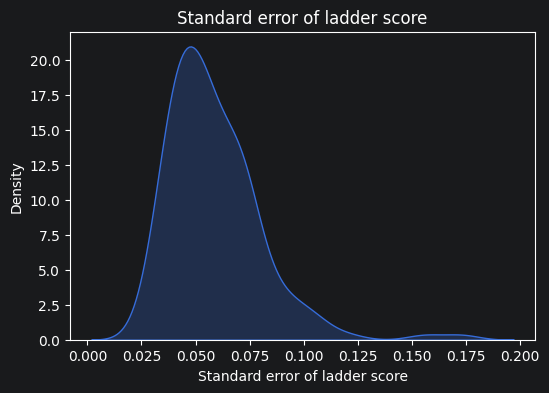

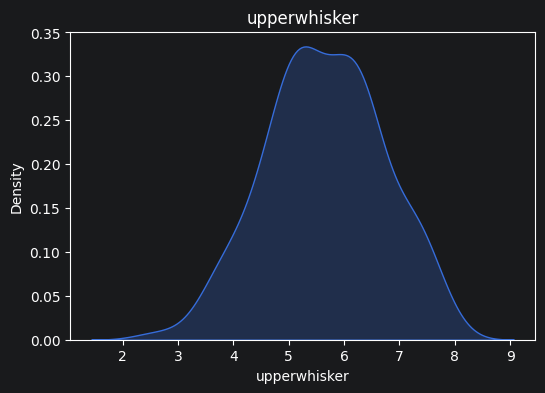

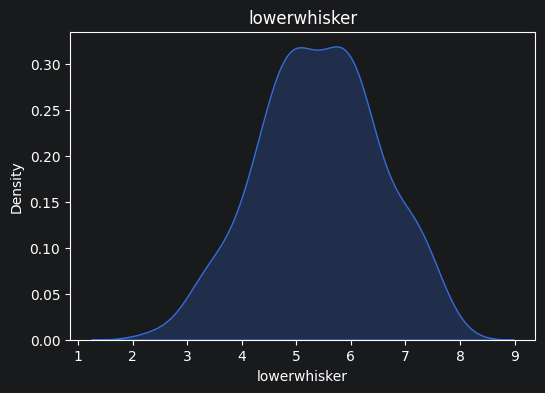

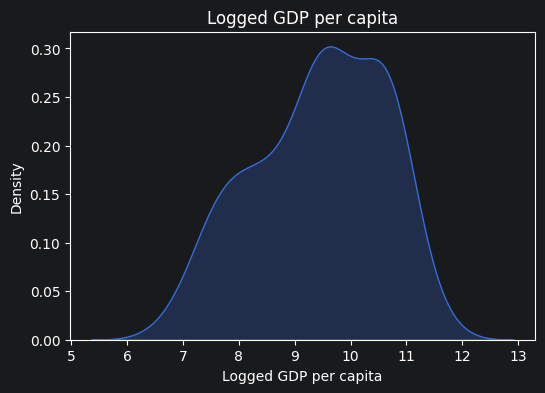

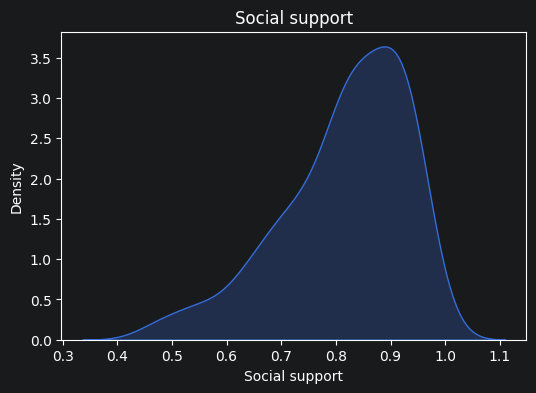

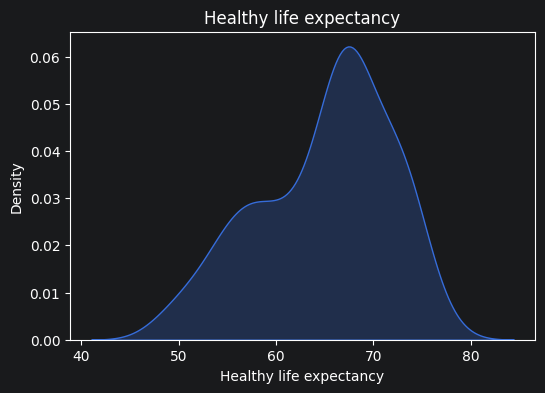

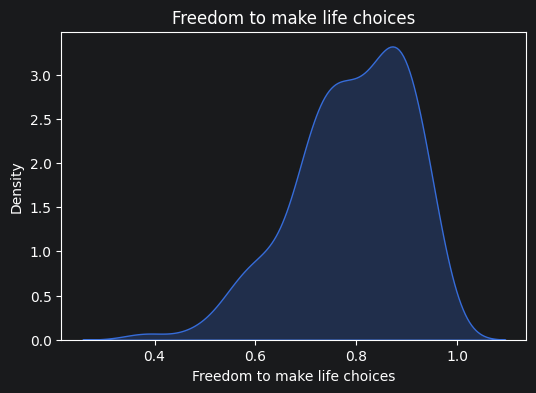

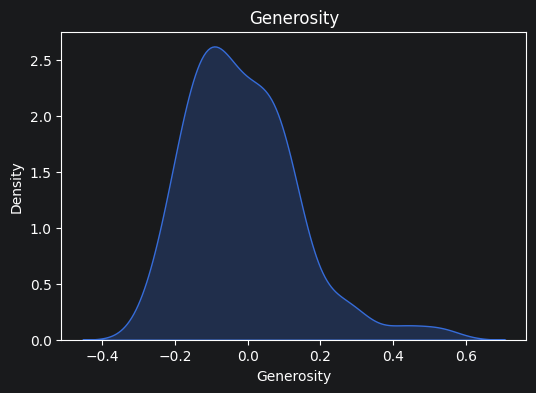

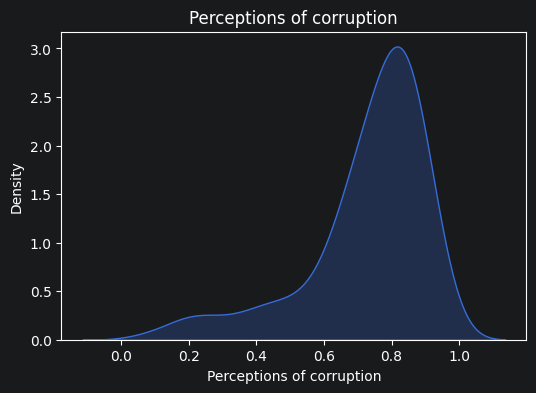

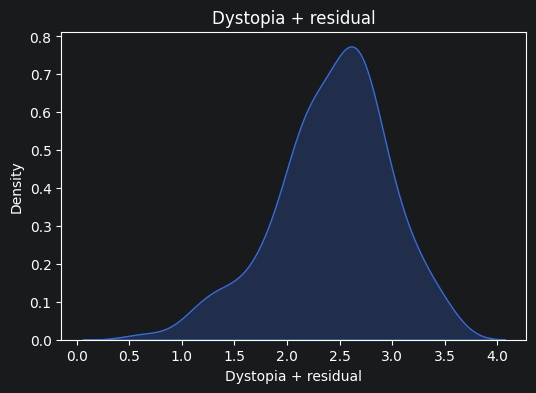

In [43]:
for col in df_num.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df_num[col], fill=True)
    plt.title(col)
    plt.show()

#### INSIGHTS OF KDE PLOT

* Ladder Score: Distribution appears fairly smooth and close to normal.
* Standard Error of Ladder Score: Values are concentrated with low variation.
* Upperwhisker: Moderate spread with fairly balanced distribution.
* Lowerwhisker: Shows similar balanced distribution with some variation.
* Logged GDP per Capita: Moderate spread, slight skewness may be present.
* Social Support: Values are concentrated, suggesting consistency.
* Healthy Life Expectancy: Fairly smooth distribution with moderate spread.
* Freedom to Make Life Choices: Some variation with slight skewness.
* Generosity: Wider spread, showing more variability.
* Perceptions of Corruption: Broad distribution with noticeable variation.
* Dystopia + Residual: Moderate spread and relatively smooth pattern.

Overall:

Most variables show smooth distributions.
Some are approximately normal, while others show slight skewness.
Generosity and Corruption show greater variability compared to others.

## Pie chart

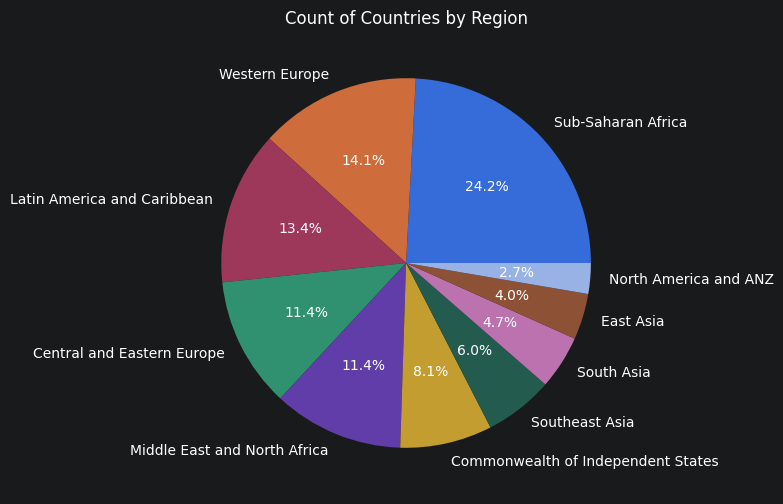

In [44]:
region_counts = df_new['region'].value_counts()

plt.figure(figsize=(10,6))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%')
plt.title('Count of Countries by Region')
plt.show()

#### INSIGHTS OF PIE CHART

* Sub-Saharan Africa has the most countries (24.2%).
* Western Europe and Latin America also have many countries.
* Central and Eastern Europe and Middle East and North Africa have similar counts.
* North America and ANZ has the fewest countries (2.7%).
* The data is not evenly distributed across regions.
* Most countries in the dataset come from Africa and Europe.

# Bivariate analysis

## Bar plot

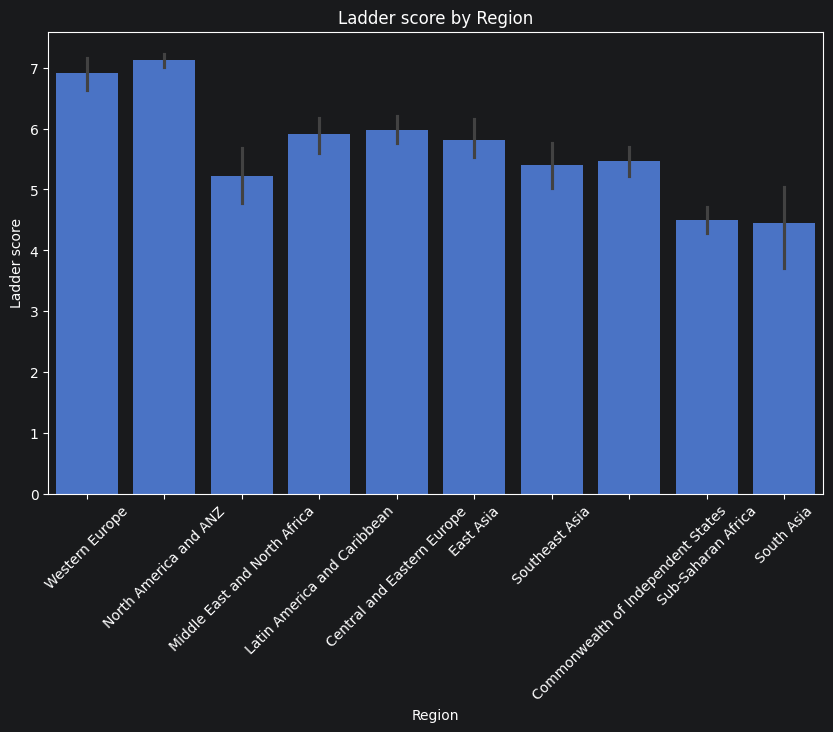

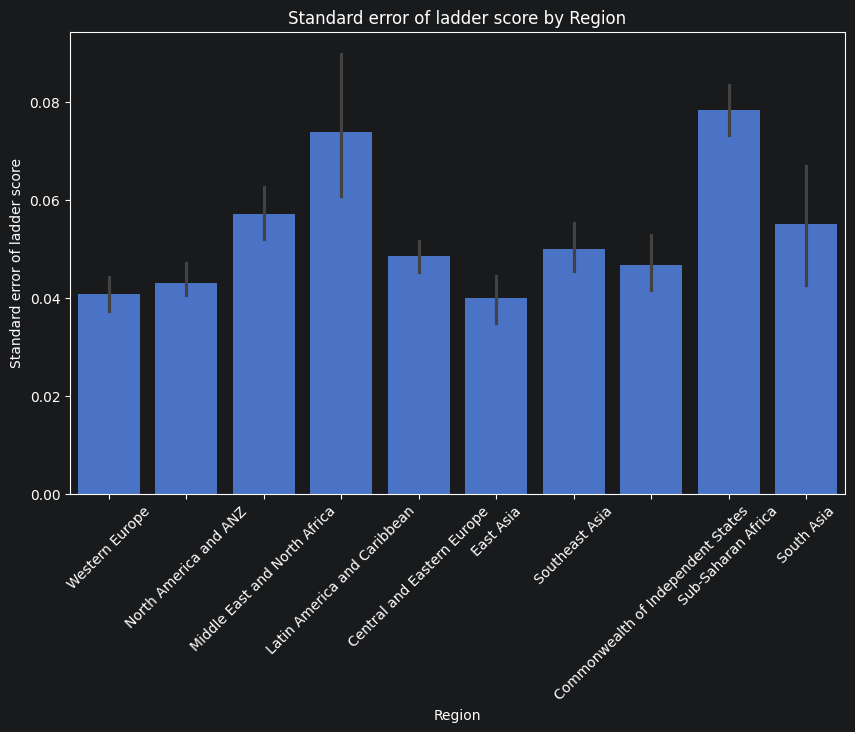

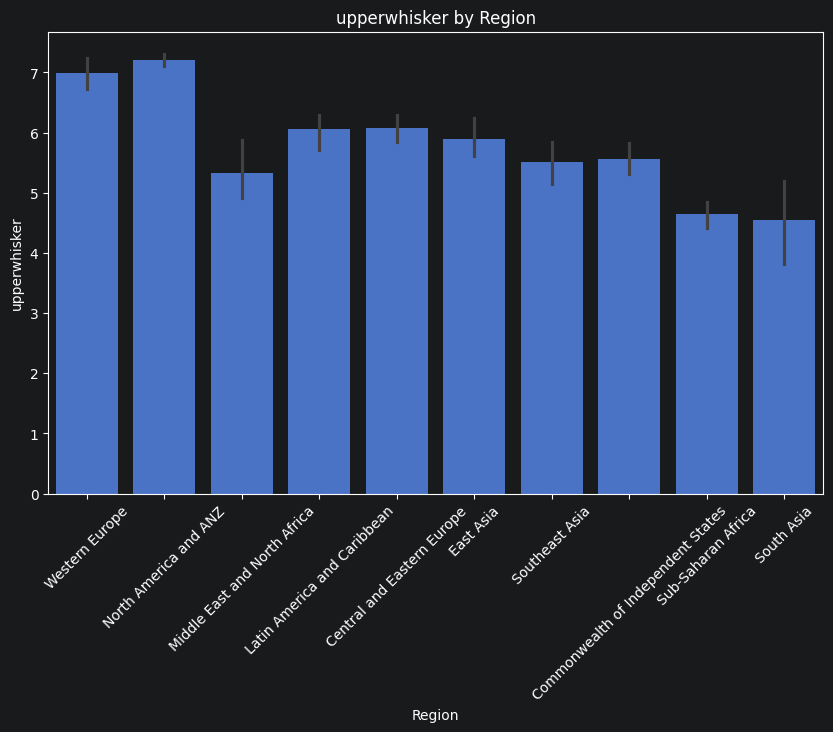

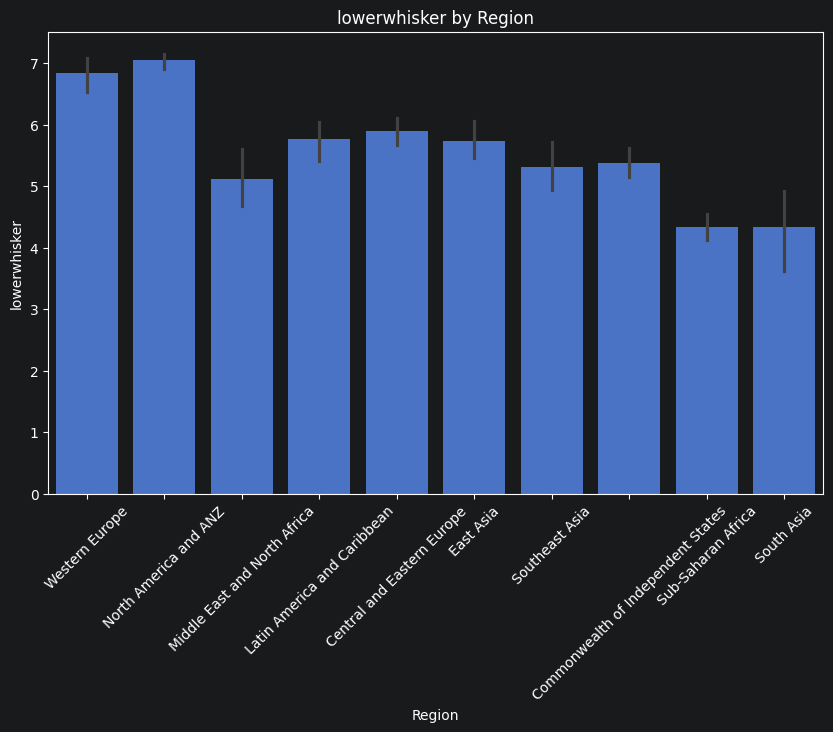

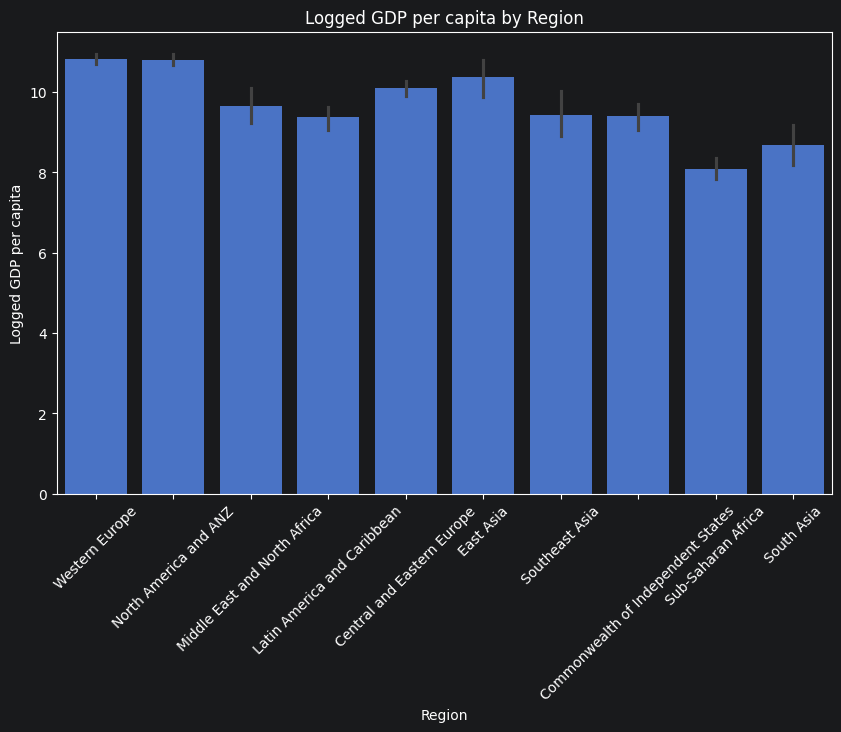

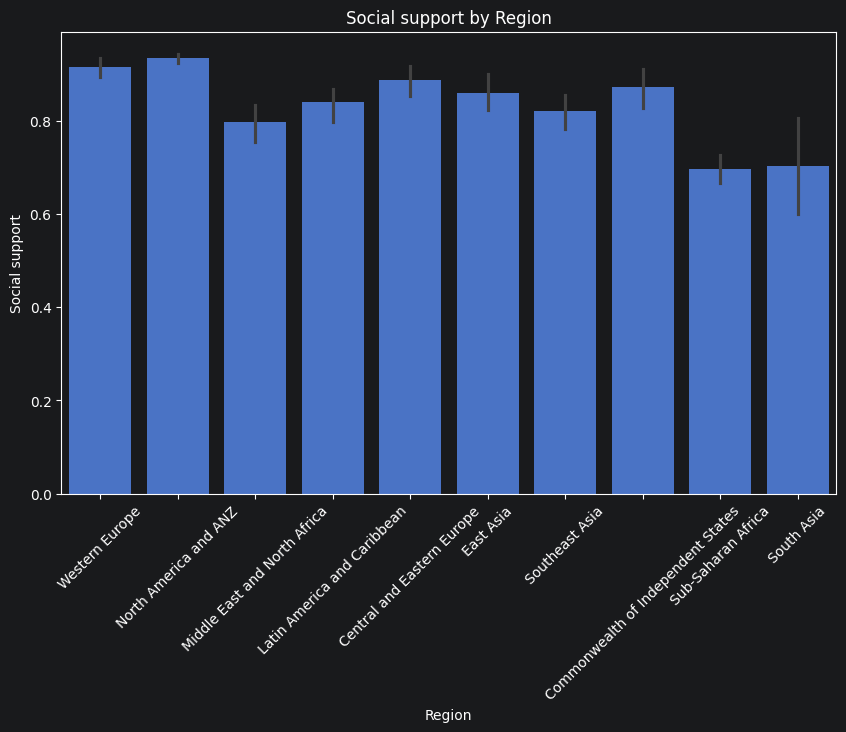

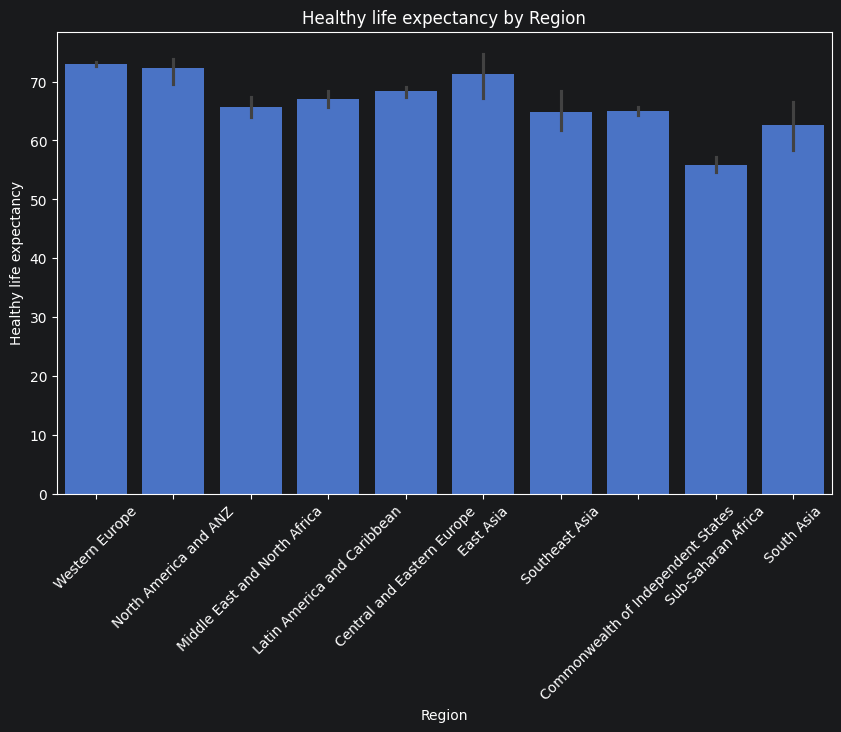

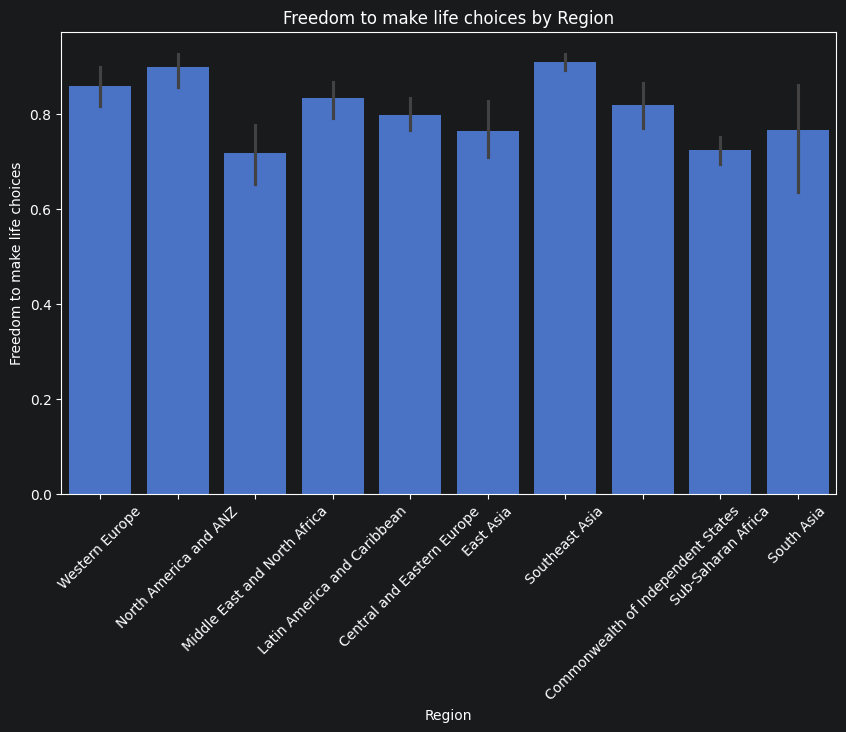

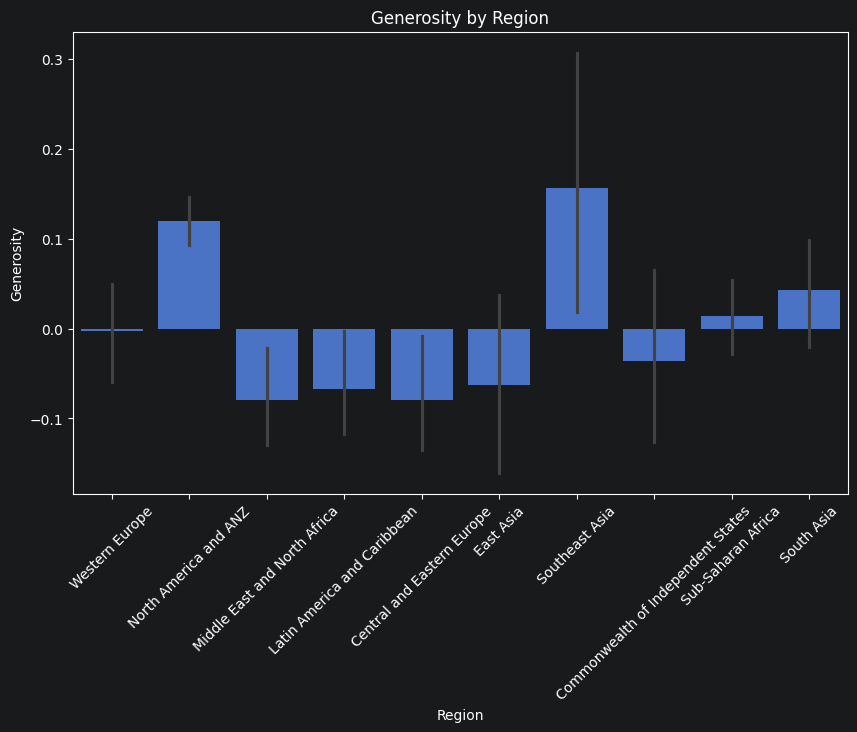

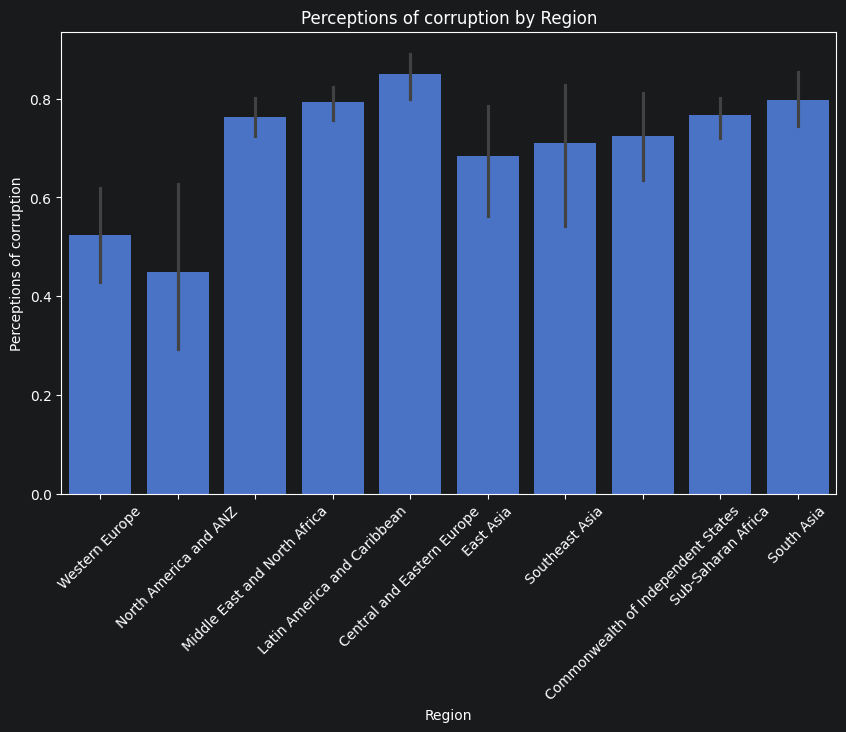

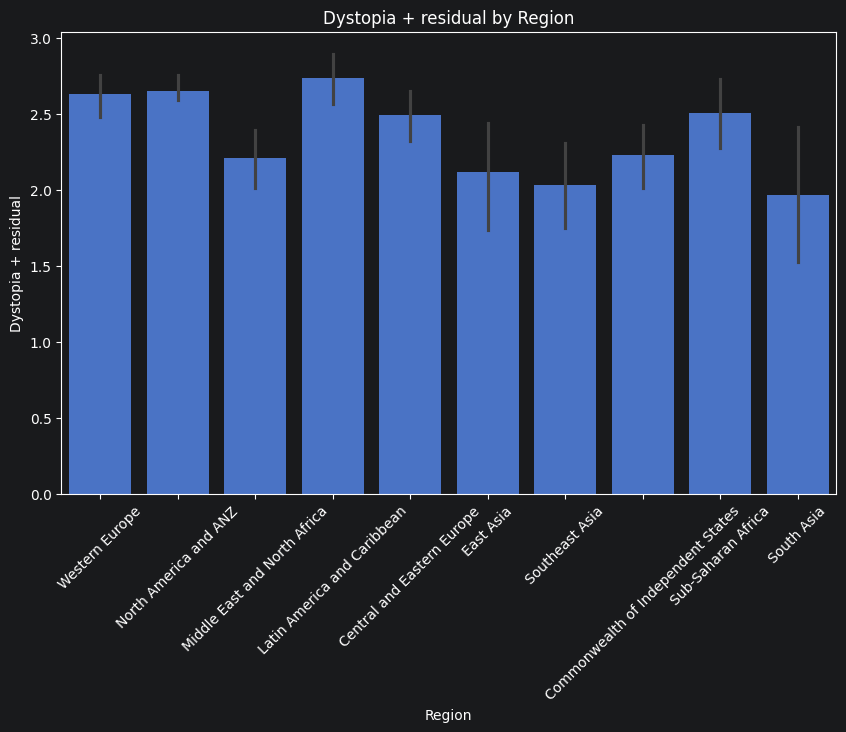

In [45]:
num_cols = [
    'Ladder score',
    'Standard error of ladder score',
    'upperwhisker',
    'lowerwhisker',
    'Logged GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'Dystopia + residual'
]

for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='region', y=col, data=df_new)

    plt.title(f'{col} by Region')
    plt.xlabel('Region')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

### Insights of Bar plot

* **Ladder Score**: Shows differences in happiness levels across regions; some regions have higher average happiness than others.
* **Standard Error of Ladder Score**: Indicates variation in happiness scores; lower values suggest more consistency within a region.
* **Upperwhisker and Lowerwhisker**: Show the spread or range of happiness scores across regions.
* **Logged GDP per Capita**: Some regions have higher economic prosperity, which may relate to higher happiness.
* **Social Support**: Regions differ in the level of support people feel they receive.
* **Healthy Life Expectancy**: Highlights regional differences in health and longevity.
* **Freedom to Make Life Choices**: Some regions show greater perceived freedom than others.
* **Generosity**: Levels of generosity vary across regions, showing social behavior differences.
* **Perceptions of Corruption**: Regions differ in how corruption is perceived, which can affect wellbeing.
* **Dystopia + Residual**: Captures unexplained factors contributing to happiness and varies by region.

Overall Insight:

* Clear regional variations are visible in most variables.
* Economic, social, health, and governance factors appear to influence happiness differently across regions.
* Some regions may consistently perform higher across multiple indicators, while others may lag behind.

## Scatter diegram

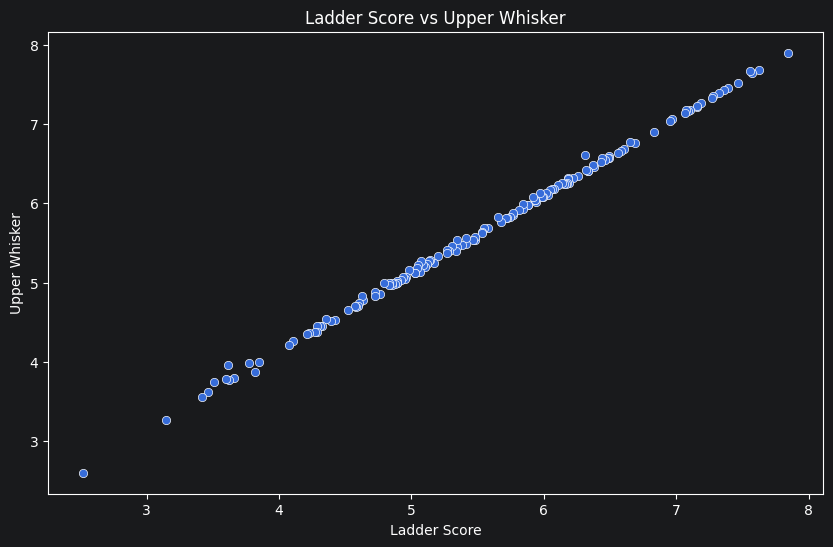

In [46]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Ladder score', y='upperwhisker', data=df_new)

plt.title('Ladder Score vs Upper Whisker')
plt.xlabel('Ladder Score')
plt.ylabel('Upper Whisker')
plt.show()

Insights
* Shows a strong positive relationship.
* As happiness score increases, the upper whisker also increases.
* Points close together suggest consistency in the data.

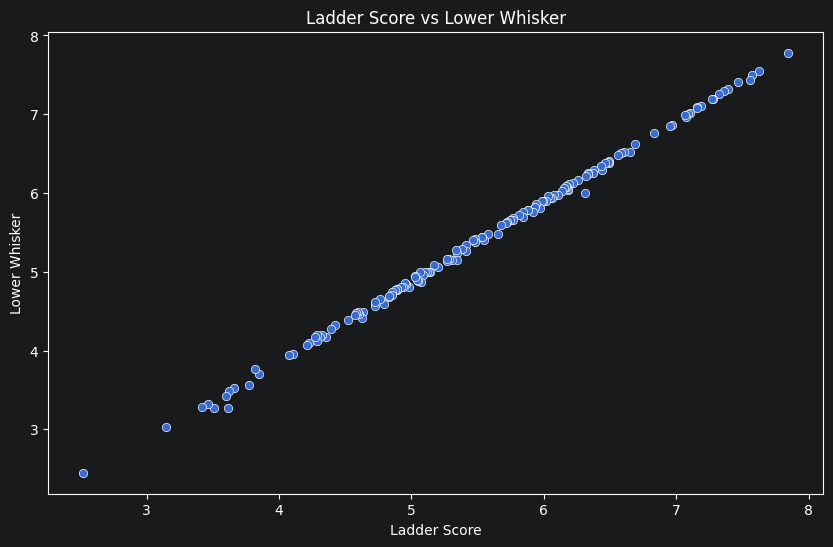

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Ladder score', y='lowerwhisker', data=df_new)

plt.title('Ladder Score vs Lower Whisker')
plt.xlabel('Ladder Score')
plt.ylabel('Lower Whisker')
plt.show()

Insights
* Strong positive correlation is observed.
* Higher happiness scores are associated with higher lower whisker values.
* Indicates stable confidence intervals around scores.

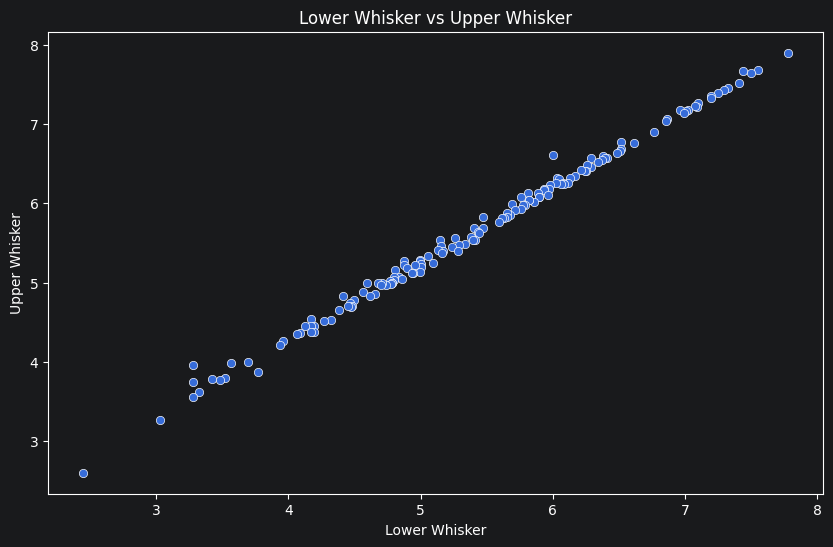

In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='lowerwhisker', y='upperwhisker', data=df_new)

plt.title('Lower Whisker vs Upper Whisker')
plt.xlabel('Lower Whisker')
plt.ylabel('Upper Whisker')
plt.show()

Insights
* Very strong positive linear relationship.
* Both measures move together, showing reliability in the estimates.

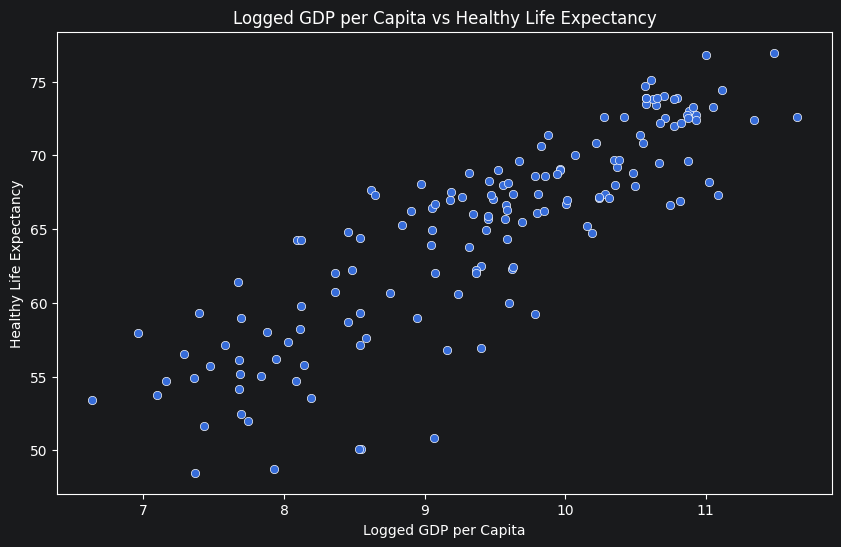

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Logged GDP per capita', y='Healthy life expectancy', data=df_new)

plt.title('Logged GDP per Capita vs Healthy Life Expectancy')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Healthy Life Expectancy')
plt.show()

Insights
* Positive correlation suggests countries with higher GDP tend to have higher life expectancy.
* Indicates economic growth may support better health outcomes.

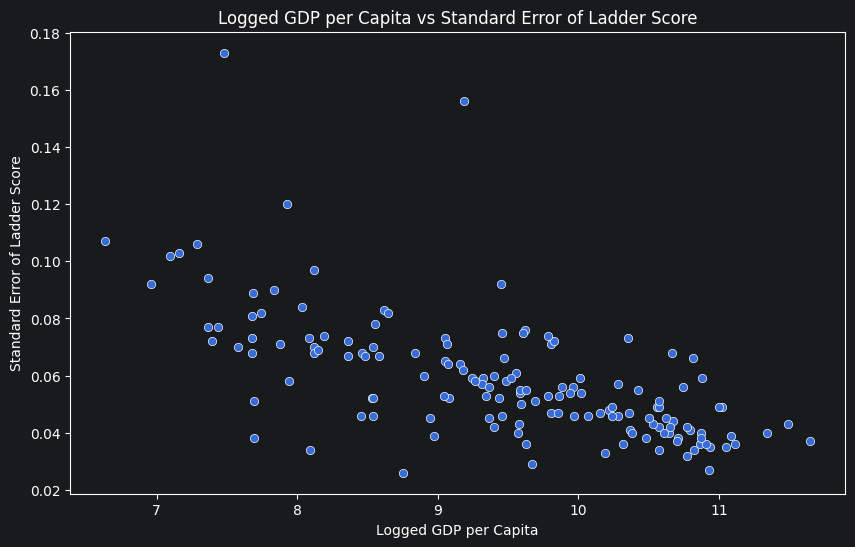

In [50]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Logged GDP per capita', y='Standard error of ladder score', data=df_new)

plt.title('Logged GDP per Capita vs Standard Error of Ladder Score')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Standard Error of Ladder Score')
plt.show()

Insights
* Weak or unclear relationship may be observed.
* GDP does not strongly influence variation in happiness score estimates.

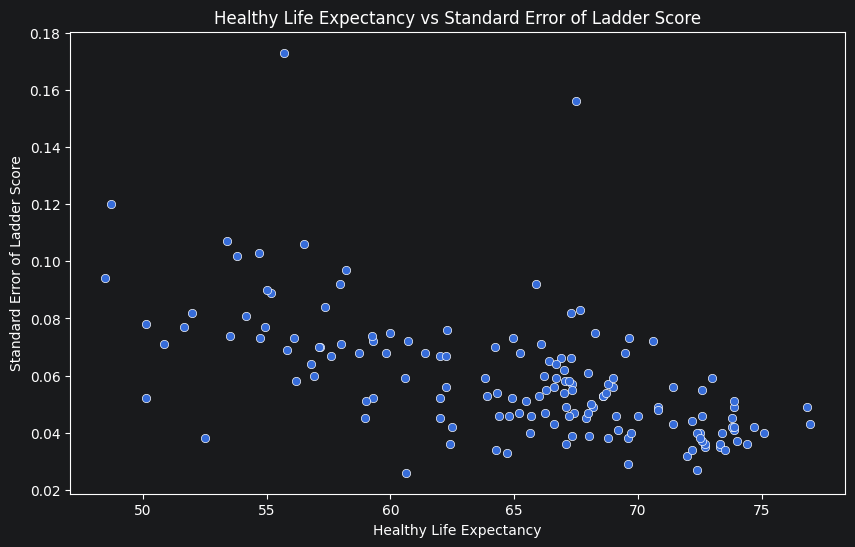

In [51]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Healthy life expectancy', y='Standard error of ladder score', data=df_new)

plt.title('Healthy Life Expectancy vs Standard Error of Ladder Score')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Standard Error of Ladder Score')
plt.show()

Insights
* Weak or unclear relationship may be observed.
* GDP does not strongly influence variation in happiness score estimates.

Insights


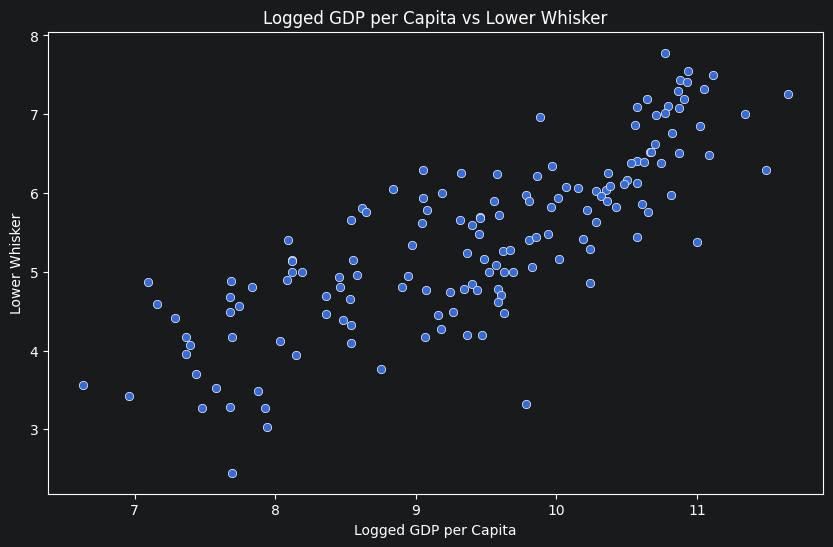

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Logged GDP per capita', y='lowerwhisker', data=df_new)

plt.title('Logged GDP per Capita vs Lower Whisker')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Lower Whisker')
plt.show()

Insights
* Positive relationship observed — wealthier nations show higher happiness lower bounds.
* GDP is a reliable predictor of the minimum happiness confidence level.

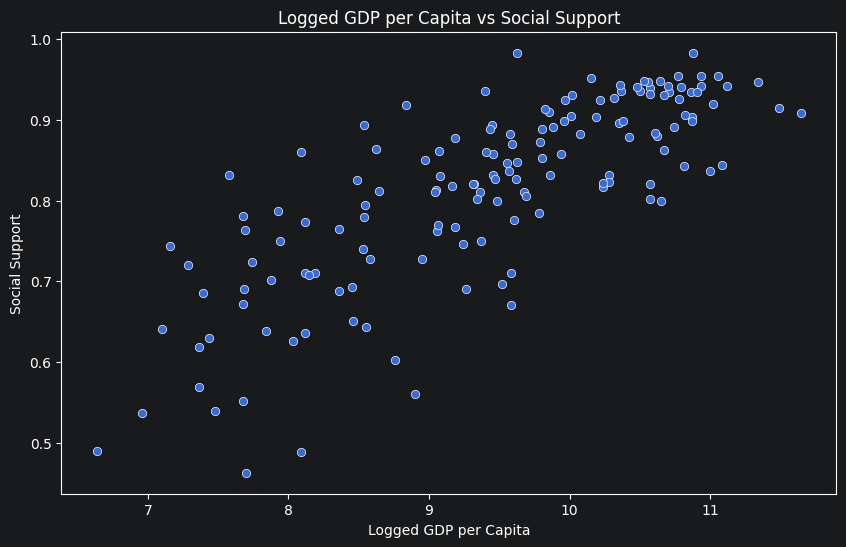

In [53]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Logged GDP per capita', y='Social support', data=df_new)

plt.title('Logged GDP per Capita vs Social Support')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Social Support')
plt.show()

Insights
* Strong positive correlation between logged GDP per capita and social support.
* Higher-income countries tend to report greater social support scores.

# MULTIVARIATE ANALYSIS

## HEAT MAP

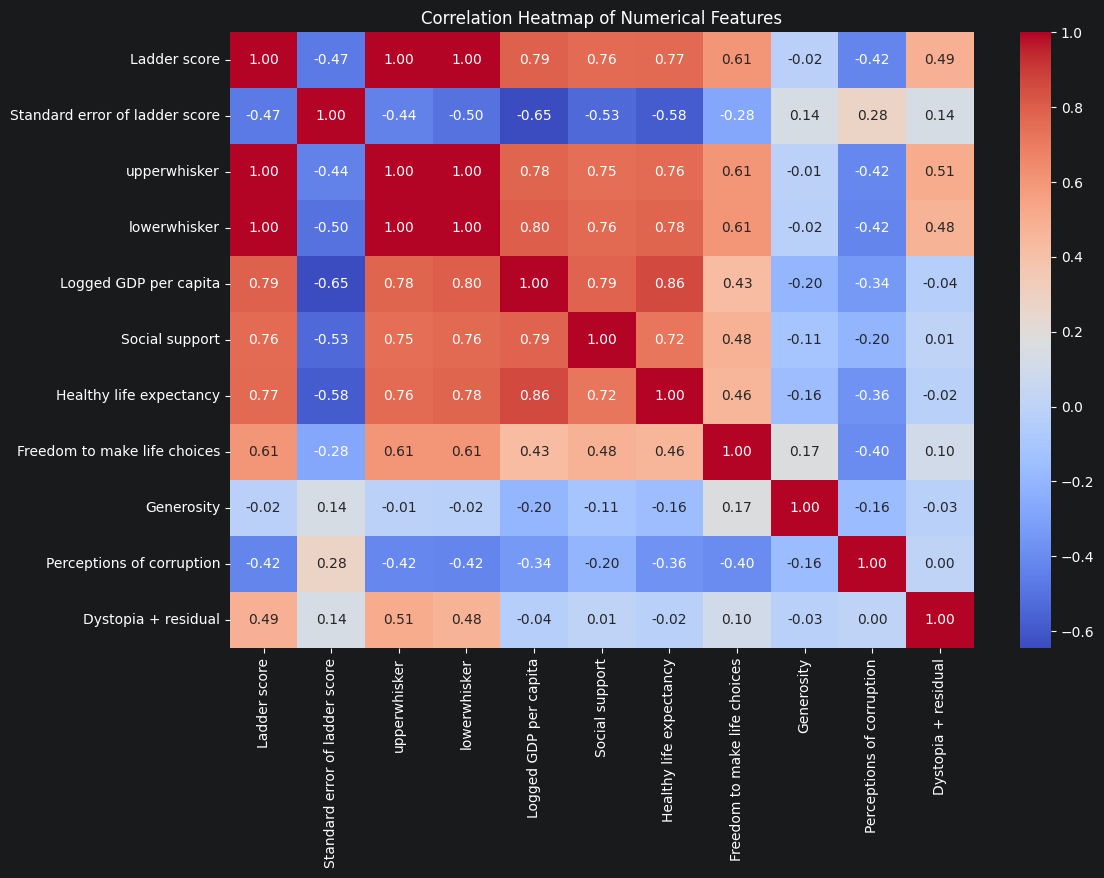

In [54]:
plt.figure(figsize=(12,8))
sns.heatmap(df_new[num_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### INSIGHTS OF HEAT MAP

* GDP per capita has a positive relation with happiness, showing wealth can improve well-being.
* Social support shows a strong link with happiness, making it a key factor.
* Healthy life expectancy is positively related to happiness, showing health matters.
* Freedom to make life choices also contributes to higher happiness.
* Generosity has a weaker effect compared to other factors.
* Overall, economic, social, and health factors are major drivers of happiness in the dataset.

#### LINE PLOT

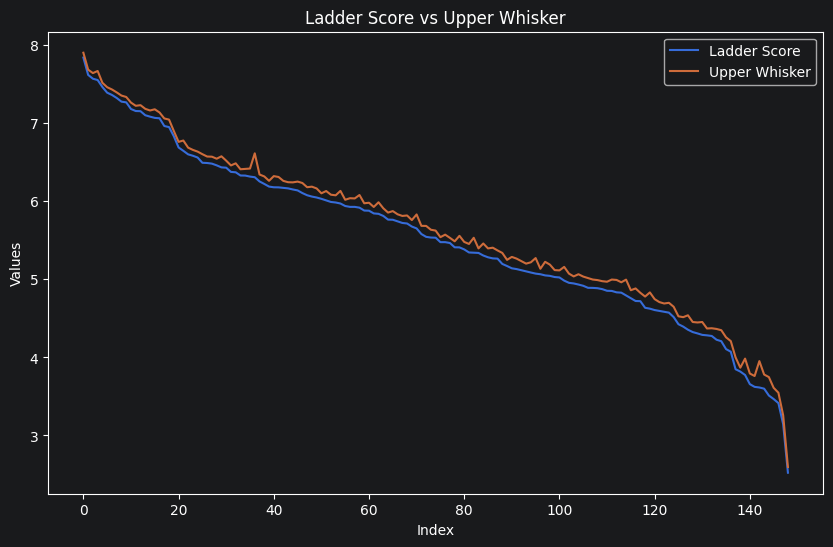

In [55]:
plt.figure(figsize=(10,6))

sns.lineplot(x=df_new.index, y='Ladder score', data=df_new, label='Ladder Score')
sns.lineplot(x=df_new.index, y='upperwhisker', data=df_new, label='Upper Whisker')

plt.title('Ladder Score vs Upper Whisker')
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.show()

Insights

* Ladder Score and Upper Whisker follow a very similar trend, showing a strong positive relationship.
* Both gradually decrease, indicating lower happiness scores across lower-ranked countries.
* Upper Whisker stays slightly above Ladder Score, showing the upper confidence range.
* The small gap between the lines suggests low variation and consistent data.
* A sharp drop at the end shows some countries have much lower happiness scores.


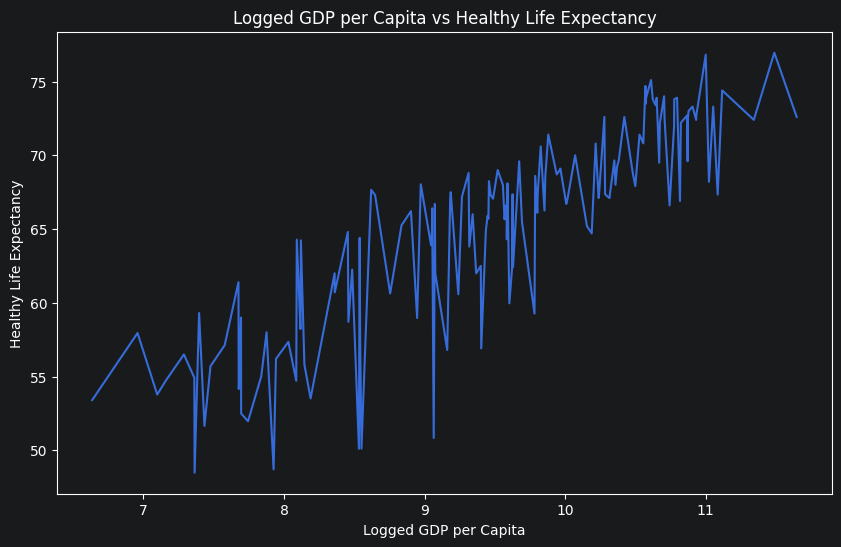

In [56]:
plt.figure(figsize=(10,6))

sns.lineplot(x='Logged GDP per capita',
             y='Healthy life expectancy',
             data=df_new)

plt.title('Logged GDP per Capita vs Healthy Life Expectancy')
plt.xlabel('Logged GDP per Capita')
plt.ylabel('Healthy Life Expectancy')

plt.show()

insights
* Positive trend observed — higher GDP corresponds to longer healthy life expectancy.
* High variability in the line suggests GDP is not the sole influencing factor.


DAY-7

## REGRESSION PLOT(Regplot)

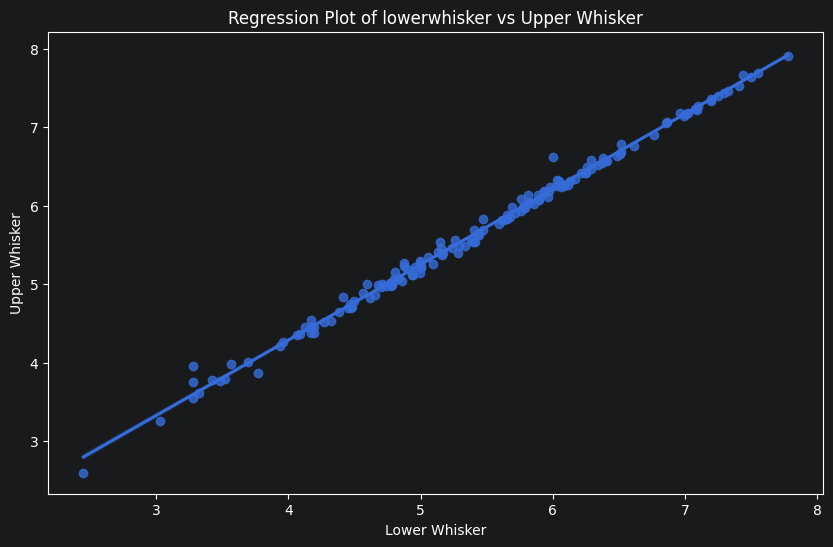

In [57]:
plt.figure(figsize=(10,6))
sns.regplot(x='lowerwhisker',
            y='upperwhisker',
            data=df_new)

plt.title('Regression Plot of lowerwhisker vs Upper Whisker')
plt.xlabel('Lower Whisker')
plt.ylabel('Upper Whisker')
plt.show()

#### Insights
* Near-perfect linear relationship observed between lower and upper whisker values.
* Suggests the confidence interval width remains consistent across all happiness levels.
* Minimal scatter around the regression line indicates very low residual variance.
* One notable outlier near lower whisker ~6 with a high upper whisker value (~6.6) breaks the pattern slightly.

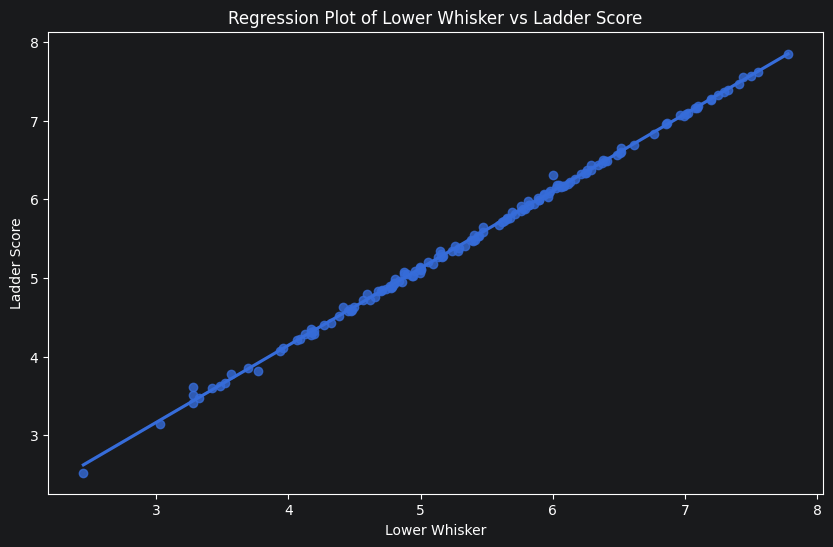

In [58]:
plt.figure(figsize=(10,6))
sns.regplot(x='lowerwhisker',
            y='Ladder score',
            data=df_new)

plt.title('Regression Plot of Lower Whisker vs Ladder Score')
plt.xlabel('Lower Whisker')
plt.ylabel('Ladder Score')
plt.show()

#### Insights

 *  Very strong positive linear relationship between lower whisker and ladder score.
 *  Points closely follow the regression line, indicating a high R² value.
 *  A few outliers are visible around ladder score 6.2, slightly deviating from the trend.
 *  lower whisker reliably predicts the ladder score, making it a strong confidence measure.



## CONCLUTION

The statistical summary shows that most variables have moderate spread and are reasonably well distributed, though some exhibit slight skewness. Variables such as Social Support and Standard Error show low variation, while Generosity and Perceptions of Corruption show higher variability. Overall, the dataset appears complete, balanced, and suitable for further analysis, with no major issues related to missing values or extreme irregularities.